In [3]:
import pandas as pd

relationships = pd.read_csv('/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/relationships.csv', low_memory=False)
others = pd.read_csv('/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/nodes-others.csv', low_memory=False)
officers = pd.read_csv('/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/nodes-officers.csv', low_memory=False)
intermeds = pd.read_csv('/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/nodes-intermediaries.csv', low_memory=False)
entities = pd.read_csv('/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/nodes-entities.csv', low_memory=False)
addys = pd.read_csv('/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/nodes-addresses.csv', low_memory=False)

In [4]:
# Define legitimate leak sources only (exclude corporate registries)
LEAK_SOURCES = [
    'Panama Papers',
    'Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)',
    'Pandora Papers - SFM Corporate Services',
    'Pandora Papers - Trident Trust',
    'Pandora Papers - Commence Overseas',
    'Pandora Papers - Alpha Consulting',
    'Pandora Papers - Fidelity Corporate Services',
    'Pandora Papers - CILTrust International',
    'Pandora Papers - Il Shin Corporate Consulting Limited',
    'Pandora Papers - Overseas Management Company (OMC)',
    'Pandora Papers - Asiaciti Trust',
    'Paradise Papers - Appleby',
    'Offshore Leaks',
    'Bahamas Leaks'
]

# Filter officers and entities to leak sources only
officers_leaks = officers[officers['sourceID'].isin(LEAK_SOURCES)]
entities_leaks = entities[entities['sourceID'].isin(LEAK_SOURCES)]

print(f"Officers after filter: {len(officers_leaks):,} (was {len(officers):,})")
print(f"Entities after filter: {len(entities_leaks):,} (was {len(entities):,})")

Officers after filter: 498,221 (was 771,315)
Entities after filter: 549,194 (was 814,344)


In [5]:
# Step 1: get all "officer_of" relationships
officer_of = relationships[relationships['rel_type'] == 'officer_of'][['node_id_start', 'node_id_end']]

# Step 2: bring in officer country (filtered)
officer_of = officer_of.merge(
    officers_leaks[['node_id', 'countries']].rename(columns={'countries': 'officer_country'}),
    left_on='node_id_start',
    right_on='node_id'
).drop(columns='node_id')

# Step 3: bring in entity jurisdiction (filtered)
officer_of = officer_of.merge(
    entities_leaks[['node_id', 'jurisdiction_description']].rename(columns={'jurisdiction_description': 'entity_jurisdiction'}),
    left_on='node_id_end',
    right_on='node_id'
).drop(columns='node_id')

print(f"Total officer→entity links after filter: {len(officer_of):,}")
print(officer_of.head())

Total officer→entity links after filter: 928,185
   node_id_start  node_id_end officer_country entity_jurisdiction
0       12195425     10000601           China               Samoa
1       12160432     10000601           Samoa               Samoa
2       12160432     10002138           Samoa               Samoa
3       12139073     10002138           China               Samoa
4       12123941     10002138           China               Samoa


In [6]:
# Drop missing and unknowns
flow = officer_of[
    officer_of['officer_country'].notna() &
    officer_of['entity_jurisdiction'].notna() &
    (~officer_of['officer_country'].isin(['Not identified', 'Not Identified']))
].copy()

# Explode semicolon-separated countries
flow['officer_country'] = flow['officer_country'].str.split(';')
flow = flow.explode('officer_country')
flow['officer_country'] = flow['officer_country'].str.strip()

# Top 12 officer countries, top 10 jurisdictions by volume
top_countries = flow['officer_country'].value_counts().head(12).index
top_jurisdictions = flow['entity_jurisdiction'].value_counts().head(10).index

flow_filtered = flow[
    flow['officer_country'].isin(top_countries) &
    flow['entity_jurisdiction'].isin(top_jurisdictions)
]

# Raw count pivot
flow_matrix = flow_filtered.pivot_table(
    index='officer_country',
    columns='entity_jurisdiction',
    aggfunc='size',
    fill_value=0
)

# Sort rows and columns by total volume
flow_matrix = flow_matrix.loc[
    flow_matrix.sum(axis=1).sort_values(ascending=False).index,
    flow_matrix.sum(axis=0).sort_values(ascending=False).index
]

print(flow_matrix)

entity_jurisdiction     British Virgin Islands  Bermuda  Samoa  \
officer_country                                                  
United Kingdom                           12101    52689   4318   
United States                             8125    57844    390   
British Virgin Islands                   68829     1359    692   
Hong Kong                                48438     8734   2786   
Bermuda                                   1073    65044      3   
Singapore                                51759     2316   5040   
China                                    38734     4545   8437   
Indonesia                                47885      278   3285   
Thailand                                 40546      349    138   
Taiwan                                   19529      838  18295   
Jersey                                   15178      728     48   
Cayman Islands                            1877     1537     85   

entity_jurisdiction     Cayman Islands  Cook Islands  Undetermined  Jersey 

In [7]:
print(officers_leaks['sourceID'].value_counts())
print(entities_leaks['sourceID'].value_counts())

sourceID
Panama Papers                                                238402
Offshore Leaks                                               107190
Paradise Papers - Appleby                                     76915
Bahamas Leaks                                                 25262
Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)     23895
Pandora Papers - SFM Corporate Services                        8236
Pandora Papers - Trident Trust                                 5465
Pandora Papers - Commence Overseas                             4021
Pandora Papers - Alpha Consulting                              2746
Pandora Papers - Fidelity Corporate Services                   2482
Pandora Papers - CILTrust International                        2079
Pandora Papers - Il Shin Corporate Consulting Limited           869
Pandora Papers - Overseas Management Company (OMC)              439
Pandora Papers - Asiaciti Trust                                 220
Name: count, dtype: int64
sourceID
Pana

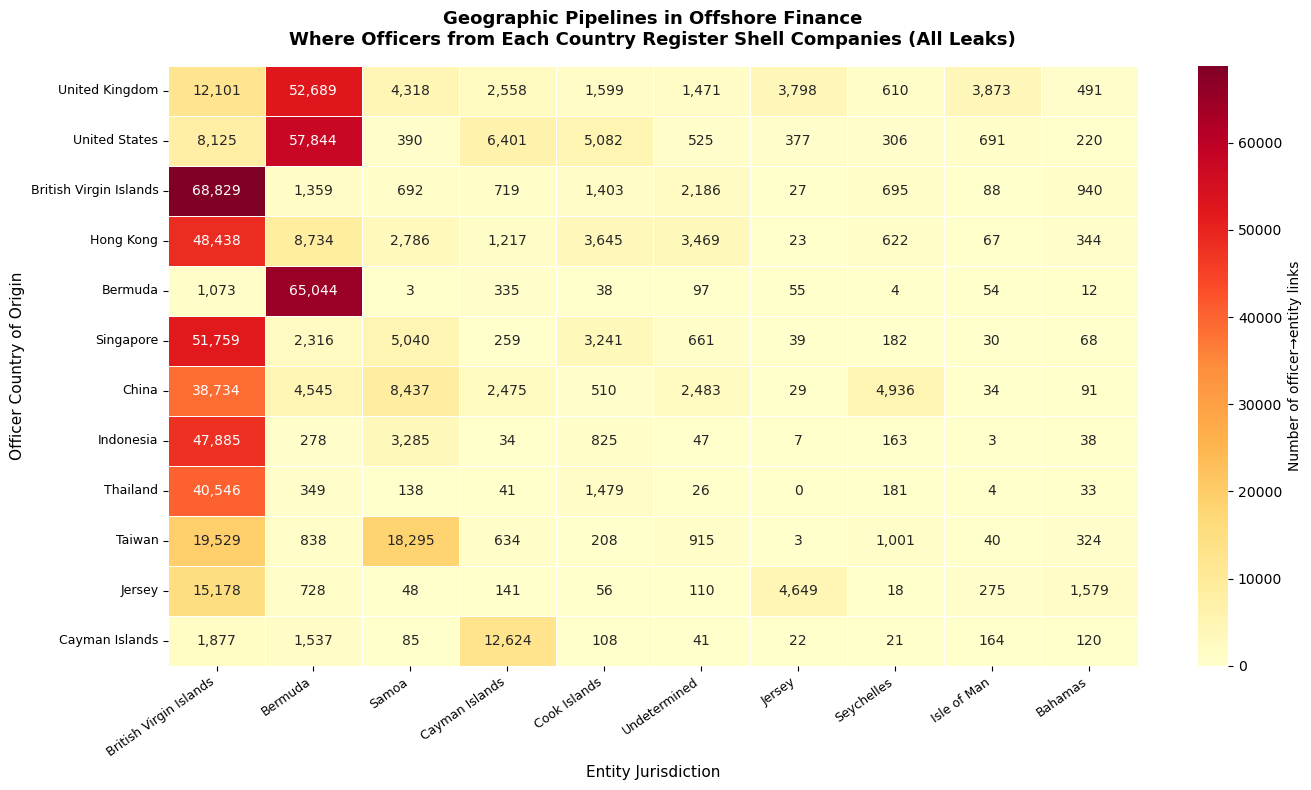

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    flow_matrix,
    annot=True,
    fmt=',',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Number of officer→entity links'}
)

ax.set_title(
    'Geographic Pipelines in Offshore Finance\nWhere Officers from Each Country Register Shell Companies (All Leaks)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Entity Jurisdiction', fontsize=11)
ax.set_ylabel('Officer Country of Origin', fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('viz3_flow_heatmap_allleaks.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import plotly.graph_objects as go

# Coordinates for top countries and jurisdictions
coords = {
    'United Kingdom': (51.5, -0.1),
    'United States': (37.1, -95.7),
    'British Virgin Islands': (18.4, -64.6),
    'Hong Kong': (22.3, 114.2),
    'Bermuda': (32.3, -64.8),
    'Singapore': (1.3, 103.8),
    'China': (35.9, 104.2),
    'Indonesia': (-0.8, 113.9),
    'Thailand': (15.9, 100.9),
    'Taiwan': (23.7, 121.0),
    'Jersey': (49.2, -2.1),
    'Cayman Islands': (19.3, -81.4),
    'Samoa': (-13.8, -172.1),
    'Cook Islands': (-21.2, -159.8),
    'Seychelles': (-4.7, 55.5),
    'Isle of Man': (54.2, -4.5),
    'Bahamas': (25.0, -77.4),
    'Undetermined': None  # skip
}

In [10]:
# Use flow_filtered from earlier (already cleaned, exploded, filtered)
flow_counts = (
    flow_filtered
    .groupby(['officer_country', 'entity_jurisdiction'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

# Keep only rows where we have coordinates for both ends
flow_counts = flow_counts[
    flow_counts['officer_country'].isin(coords.keys()) &
    flow_counts['entity_jurisdiction'].isin(coords.keys()) &
    flow_counts['officer_country'].map(lambda x: coords[x] is not None) &
    flow_counts['entity_jurisdiction'].map(lambda x: coords[x] is not None)
]

# Top 40 flows
top_flows = flow_counts.head(40)
print(top_flows.head(10))

            officer_country     entity_jurisdiction  count
12   British Virgin Islands  British Virgin Islands  68829
1                   Bermuda                 Bermuda  65044
110           United States                 Bermuda  57844
100          United Kingdom                 Bermuda  52689
72                Singapore  British Virgin Islands  51759
42                Hong Kong  British Virgin Islands  48438
52                Indonesia  British Virgin Islands  47885
92                 Thailand  British Virgin Islands  40546
32                    China  British Virgin Islands  38734
82                   Taiwan  British Virgin Islands  19529


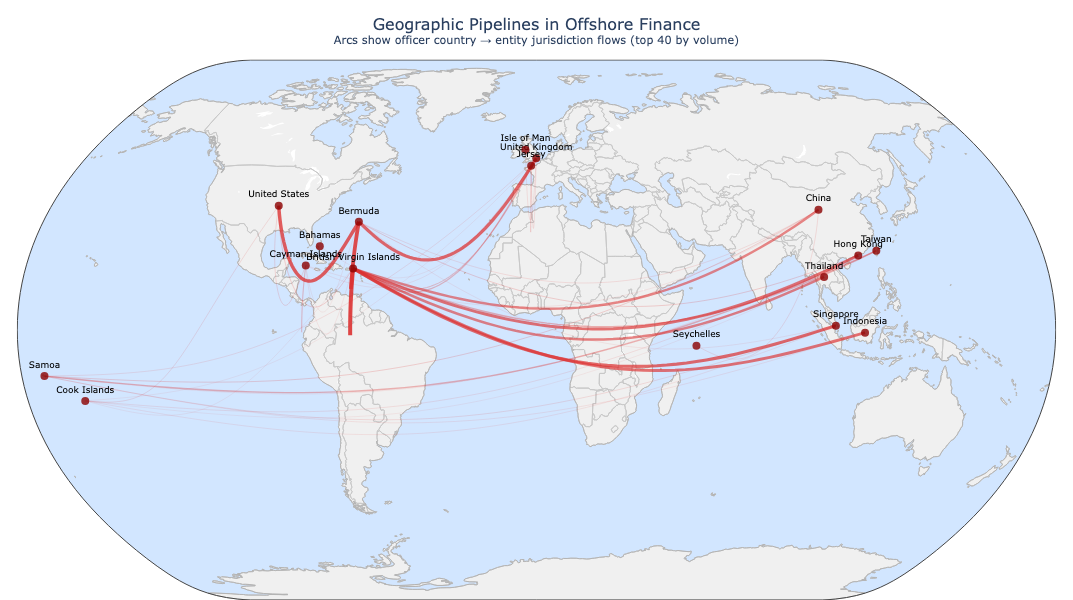

In [11]:
import numpy as np

fig = go.Figure()

# Normalize line width and opacity by count
max_count = top_flows['count'].max()
min_count = top_flows['count'].min()

def normalize(val, lo, hi, new_lo, new_hi):
    return new_lo + (val - lo) / (hi - lo) * (new_hi - new_lo)

def make_arc(src_lat, src_lon, dst_lat, dst_lon, n_points=50):
    """Create a curved arc that stays closer to the equator"""
    lats = []
    lons = []
    for t in np.linspace(0, 1, n_points):
        lat = src_lat + t * (dst_lat - src_lat)
        lon = src_lon + t * (dst_lon - src_lon)
        # Add a slight downward bow — negative pulls toward equator
        bow = -20 * np.sin(np.pi * t)
        lat += bow
        lats.append(lat)
        lons.append(lon)
    return lats, lons

# Then in your loop, replace the add_trace call with:
for _, row in top_flows.iterrows():
    src = coords[row['officer_country']]
    dst = coords[row['entity_jurisdiction']]
    count = row['count']
    
    opacity = normalize(count, min_count, max_count, 0.15, 0.9)
    width = normalize(count, min_count, max_count, 0.5, 4)
    
    lats, lons = make_arc(src[0], src[1], dst[0], dst[1])
    
    fig.add_trace(go.Scattergeo(
        lon=lons,
        lat=lats,
        mode='lines',
        line=dict(width=width, color=f'rgba(220, 50, 50, {opacity:.2f})'),
        hoverinfo='text',
        text=f"{row['officer_country']} → {row['entity_jurisdiction']}: {count:,}",
        showlegend=False
    ))


# Draw dots for each location
all_places = set(top_flows['officer_country']).union(set(top_flows['entity_jurisdiction']))
for place in all_places:
    if coords.get(place):
        lat, lon = coords[place]
        total = flow_counts[
            (flow_counts['officer_country'] == place) | 
            (flow_counts['entity_jurisdiction'] == place)
        ]['count'].sum()
        
        fig.add_trace(go.Scattergeo(
            lon=[lon], lat=[lat],
            mode='markers+text',
            marker=dict(size=8, color='darkred', opacity=0.8),
            text=place,
            textposition='top center',
            textfont=dict(size=9, color='black'),
            hoverinfo='text',
            hovertext=f"{place}: {total:,} total links",
            showlegend=False
        ))
        

fig.update_layout(
    title=dict(
        text='Geographic Pipelines in Offshore Finance<br><sup>Arcs show officer country → entity jurisdiction flows (top 40 by volume)</sup>',
        x=0.5, font=dict(size=16)
    ),
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='rgb(240, 240, 240)',
        showocean=True,
        oceancolor='rgb(210, 230, 255)',
        showcountries=True,
        countrycolor='rgb(200, 200, 200)',
        showcoastlines=True,
        coastlinecolor='rgb(180, 180, 180)',
        bgcolor='white'
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    height=600,
    paper_bgcolor='white'
)

fig.write_html('viz4_flow_map.html')
fig.show()



In [12]:
# What share of all entities in the leak data are registered in BVI?
bvi_count = entities_leaks[entities_leaks['jurisdiction_description'] == 'British Virgin Islands'].shape[0]
total_count = entities_leaks['jurisdiction_description'].notna().sum()
bvi_share = bvi_count / total_count * 100

print(f"BVI entities: {bvi_count:,}")
print(f"Total entities with known jurisdiction: {total_count:,}")
print(f"BVI share: {bvi_share:.1f}%")

BVI entities: 172,389
Total entities with known jurisdiction: 541,632
BVI share: 31.8%


In [13]:
fig.write_image('viz4_flow_map.png', width=1400, height=700, scale=2)
print("Saved viz4_flow_map.png")

Saved viz4_flow_map.png


In [15]:
# Fix both warnings and filter out impossible dates
entities_leaks = entities_leaks.copy()  # fixes SettingWithCopyWarning
entities_leaks['incorporation_date'] = pd.to_datetime(
    entities_leaks['incorporation_date'], 
    format='mixed', 
    errors='coerce'
)

# Filter to realistic date range
dated = entities_leaks[
    (entities_leaks['incorporation_date'].dt.year >= 1950) &
    (entities_leaks['incorporation_date'].dt.year <= 2023)
]

earliest = dated['incorporation_date'].min()
latest = dated['incorporation_date'].max()
peak_year = dated['incorporation_date'].dt.year.value_counts().idxmax()
peak_count = dated['incorporation_date'].dt.year.value_counts().max()

print(f"Earliest incorporation: {earliest.year}")
print(f"Latest incorporation: {latest.year}")
print(f"Peak year: {peak_year} ({peak_count:,} entities)")
print(f"Total entities with valid dates: {len(dated):,}")

Earliest incorporation: 1950
Latest incorporation: 2023
Peak year: 2000 (35,247 entities)
Total entities with valid dates: 526,236


In [16]:
# Total unique officers, entities, jurisdictions, countries
print(f"Total entities (leak sources): {len(entities_leaks):,}")
print(f"Total officers (leak sources): {len(officers_leaks):,}")
print(f"Total unique jurisdictions: {entities_leaks['jurisdiction_description'].nunique()}")
print(f"Total unique officer countries: {officers_leaks['countries'].nunique()}")
print(f"Total relationships: {len(relationships):,}")
print(f"Total unique intermediaries: {len(intermeds):,}")

Total entities (leak sources): 549,194
Total officers (leak sources): 498,221
Total unique jurisdictions: 86
Total unique officer countries: 2582
Total relationships: 3,339,267
Total unique intermediaries: 25,629


In [17]:
status_counts = entities_leaks['status'].value_counts()
print(status_counts)

active = entities_leaks[entities_leaks['status'] == 'Active'].shape[0]
total_status = entities_leaks['status'].notna().sum()
print(f"\nActive share: {active/total_status*100:.1f}%")

status
Active                             116021
Defaulted                          100090
Dissolved                           24082
Dead                                23095
Struck / Defunct / Deregistered     19486
                                    ...  
Terminated                              1
strike off                              1
Not Renewed by Client                   1
struck off                              1
dormant                                 1
Name: count, Length: 73, dtype: int64

Active share: 35.1%
